# Smart Factory Safety Agent — 설비 위험 Visual RAG

[AI Hub 스마트 제조 시설 안전 감시 데이터](https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71679) (`smart_factory_human_accident.zip`)를 이용해
**설비 이미지 → Vision AI → AI Agent → Vector DB + 안전 매뉴얼 → LLM 종합 판단 → 점검 보고서** 파이프라인을 실습합니다.

> **선행 학습**: `01_visual_rag_clip_siglip2_chromadb_qwen3vl.ipynb` · `10_visual_ai_agent.ipynb`

## 전체 흐름

```
설비 이미지 (CCTV PNG)
       ↓
Vision AI — 라벨 bbox + 공간 관계 → 설비/위험상황 인식
       ↓
AI Agent Orchestrator (Tool Calling)
       ↓
┌──────────────────────────────────────────────────────┐
│ search_similar_cases │ SigLIP2 → ChromaDB 유사 사례   │
│ search_safety_manual │ 안전 매뉴얼(PDF→JSON) 절차 검색 │
│ recognize_hazard     │ Vision AI 위험 인식 (선택 Qwen)│
└──────────────────────────────────────────────────────┘
       ↓
LLM 종합 판단 → 점검 결과·조치사항 Markdown 보고서
```

| Agent 구성 | 역할 |
|-----------|------|
| **HazardRecognizer** | 라벨 JSON bbox → 끼임/근접/안전 공간 관계 추론 |
| **AccidentCaseStore** | SigLIP2 + ChromaDB 유사 사고 사례 검색 |
| **SafetyManualStore** | 끼임·낙상·충돌 등 안전 절차 하이브리드 검색 |
| **SafetyAgent** | Plan → Act → Report 자동 루프 |

### 모듈·데이터 참조

📄 **[00_모듈_참조.md](00_모듈_참조.md)**

| 구성요소 | 경로 |
|----------|------|
| AI Hub 데이터셋 | `smart_factory_human_accident.zip` → `data/smart_factory/` |
| ChromaDB (유사 사례) | `data/smart_factory/chroma_db/` |
| 안전 매뉴얼 (PDF 대체 JSON) | `data/agent/safety_manual.json` |
| 생성 보고서 | `data/agent/reports/` |
| SigLIP2 인코더 | `conveyor_analyze/conveyor_rag/encoder.py` |

## 0. 환경 설정

| 기술 | Agent 역할 |
|------|------------|
| **SigLIP2 + ChromaDB** | `search_similar_cases` Visual RAG |
| **라벨 JSON bbox** | `recognize_hazard` Vision AI (IoU·거리) |
| **안전 매뉴얼 JSON** | `search_safety_manual` 절차 검색 |
| **Qwen3-VL** (선택) | `USE_QWEN=True` 시 VLM 장면 분석 |

**사전 준비**
<br>
1. AI Hub에서 `smart_factory_human_accident.zip` 다운로드 → 프로젝트 루트<br>
2. `pip install -r conveyor_analyze/requirements.txt`<br>

> 유사 사례 검색·매뉴얼 검색·보고서 생성은 **GPU 없이** 실행 가능합니다.

In [ ]:
# !pip install -r conveyor_analyze/requirements.txt
# SigLIP2, ChromaDB, transformers, matplotlib 등

In [1]:
import json
import math
import re
import shutil
import sys
import zipfile
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import chromadb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image
from tqdm import tqdm

ROOT = Path(".").resolve()
ZIP_PATH = ROOT / "smart_factory_human_accident.zip"
DATA_ROOT = ROOT / "data" / "smart_factory"
CHROMA_DIR = DATA_ROOT / "chroma_db"
COLLECTION_NAME = "smart_factory_cases"
RAW_DIR_NAME = "01.원천데이터"
LABEL_DIR_NAME = "02.라벨링데이터"

AGENT_DIR = ROOT / "data" / "agent"
SAFETY_MANUAL_JSON = AGENT_DIR / "safety_manual.json"
REPORT_DIR = AGENT_DIR / "reports"

CONVEYOR_ANALYZE = ROOT / "conveyor_analyze"
sys.path.insert(0, str(CONVEYOR_ANALYZE))
from conveyor_rag.encoder import SigLIP2Encoder
from conveyor_rag.plot_utils import setup_korean_matplotlib

setup_korean_matplotlib()
AGENT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

# USE_QWEN = False  # GPU 없는 경우 QWEN3-VL 기능 생략
USE_QWEN = True # Qwen3-VL recognize_hazard VLM 분석 (GPU 권장)
TOP_K = 3
NEAR_PX = 120.0
HAZARD_IOU = 0.05

EVENT_LABELS = {
    "jam": "끼임",
    "bump": "접촉",
    "fall-down": "넘어짐",
    "fall-off": "떨어짐",
    "hit": "부딪힘",
    "no-accident": "정상",
}
FACILITY_LABELS = {
    "molding-machine": "성형기",
    "milling-machine": "밀링기",
    "injection-machine": "사출기",
}

print(f"ROOT: {ROOT}")
print(f"ZIP 존재: {ZIP_PATH.exists()}")
print(f"안전 매뉴얼: {SAFETY_MANUAL_JSON.exists()}")

ROOT: C:\MyCursorLab\09_Visual_RAG
ZIP 존재: True
안전 매뉴얼: False


## 1. 데이터셋 압축 해제 & 사례 인덱스 구축

`smart_factory_human_accident.zip`을 CP949 한글 경로로 해제하고,
PNG + JSON 라벨 쌍에서 **설비·사고유형·경로** 메타를 추출합니다.

In [2]:
def data_is_ready(root: Path) -> bool:
    if not root.exists():
        return False
    pngs = [p for p in root.rglob("*.png") if "eda" not in p.parts]
    jsons = [p for p in root.rglob("*.json") if "eda" not in p.parts]
    return len(pngs) > 0 and len(jsons) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = [p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(
            f"압축 파일 없음: {zip_path}\n"
            "AI Hub에서 smart_factory_human_accident.zip을 다운로드해 프로젝트 루트에 두세요."
        )
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        print("이미 압축 해제됨 — 스킵")
        return
    for child in extract_to.iterdir():
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            name = info.filename if (info.flag_bits & 0x800) else info.filename.encode("cp437").decode("cp949")
            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())
    print(f"압축 해제 완료: {extract_to.resolve()}")


def find_raw_and_label_roots(root: Path) -> tuple[Path, Path]:
    raw, label = root / RAW_DIR_NAME, root / LABEL_DIR_NAME
    if raw.exists() and label.exists():
        return raw, label
    dirs = [p for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return (
        max(dirs, key=lambda p: len(list(p.rglob("*.png")))),
        max(dirs, key=lambda p: len(list(p.rglob("*.json")))),
    )


def seg_to_bbox_xywh(segmentation: list[float]) -> tuple[float, float, float, float]:
    xs, ys = segmentation[0::2], segmentation[1::2]
    return min(xs), min(ys), max(xs) - min(xs), max(ys) - min(ys)


def build_case_index(raw_root: Path, label_root: Path) -> list[dict]:
    """PNG + JSON 라벨 → Agent용 사례 인덱스."""
    cases = []
    for json_path in sorted(label_root.rglob("*.json")):
        data = json.loads(json_path.read_text(encoding="utf-8-sig"))
        if "annotations" not in data:
            continue
        meta = data["meta_information"]
        rel = json_path.parent.relative_to(label_root)
        img_path = raw_root / rel / meta["file_name"]
        if not img_path.exists():
            continue
        fac = data.get("object_information_facility", {})
        hum = data.get("object_information_human", {})
        event = meta.get("event", "unknown")
        facility = fac.get("facility_name", "unknown")
        cases.append({
            "id": img_path.stem,
            "image_path": str(img_path),
            "label_path": str(json_path),
            "event": event,
            "event_ko": EVENT_LABELS.get(event, event),
            "facility": facility,
            "facility_ko": FACILITY_LABELS.get(facility, facility),
            "camera_id": meta.get("camera_id", ""),
            "shoot_time": meta.get("shoot_time", ""),
            "environment": meta.get("environment", ""),
            "human_id": hum.get("id", ""),
            "search_text": f"{event} {facility} {meta.get('environment', '')} {meta.get('shoot_time', '')}",
        })
    return cases


need_extract = not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT)
extract_zip(ZIP_PATH, DATA_ROOT, force=need_extract)

RAW_ROOT, LABEL_ROOT = find_raw_and_label_roots(DATA_ROOT)
CASE_INDEX = build_case_index(RAW_ROOT, LABEL_ROOT)
CASE_BY_ID = {c["id"]: c for c in CASE_INDEX}

print(f"원천: {RAW_ROOT.name} | 라벨: {LABEL_ROOT.name}")
print(f"인덱싱 대상: {len(CASE_INDEX)}장")
pd.DataFrame(CASE_INDEX).groupby(["event", "facility"]).size().reset_index(name="count")

압축 해제 완료: C:\MyCursorLab\09_Visual_RAG\data\smart_factory
원천: 01.원천데이터 | 라벨: 02.라벨링데이터
인덱싱 대상: 100장


,event,facility,count
0,jam,injection-machine,40
1,jam,milling-machine,40
2,jam,molding-machine,20


## 2. Vector DB — 유사 사고 사례 ChromaDB

SigLIP2 이미지 임베딩 + 사고 메타(event, facility, camera)를 ChromaDB에 저장합니다.
쿼리 이미지로 **유사 사례 Top-k**를 검색합니다.

In [3]:
class AccidentCaseStore:
    """스마트공장 사고 이미지 SigLIP2 + ChromaDB 저장·검색."""

    def __init__(self, chroma_dir: Path = CHROMA_DIR, collection_name: str = COLLECTION_NAME):
        self.client = chromadb.PersistentClient(path=str(chroma_dir))
        self.collection_name = collection_name
        self._collection = None

    @property
    def collection(self):
        if self._collection is None:
            self._collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"hnsw:space": "cosine"},
            )
        return self._collection

    def reset_collection(self):
        try:
            self.client.delete_collection(self.collection_name)
        except Exception:
            pass
        self._collection = self.client.create_collection(
            name=self.collection_name,
            metadata={"hnsw:space": "cosine"},
        )

    def build_index(self, encoder: SigLIP2Encoder, cases: list[dict], batch_size: int = 8) -> int:
        self.reset_collection()
        for i in tqdm(range(0, len(cases), batch_size), desc="ChromaDB 인덱싱"):
            batch = cases[i : i + batch_size]
            images = [Image.open(c["image_path"]).convert("RGB") for c in batch]
            embeddings = encoder.encode_images(images)
            metadatas = []
            for c in batch:
                metadatas.append({
                    "case_id": c["id"],
                    "event": c["event"],
                    "event_ko": c["event_ko"],
                    "facility": c["facility"],
                    "facility_ko": c["facility_ko"],
                    "camera_id": c["camera_id"],
                    "image_path": c["image_path"],
                    "search_text": c["search_text"],
                })
            self.collection.add(
                ids=[c["id"] for c in batch],
                embeddings=embeddings.tolist(),
                metadatas=metadatas,
            )
        return self.collection.count()

    def search_by_image(self, encoder: SigLIP2Encoder, image_path: str, top_k: int = 3) -> list[dict]:
        img = Image.open(image_path).convert("RGB")
        emb = encoder.encode_images([img])[0].tolist()
        return self._query(emb, top_k)

    def search_by_text(self, encoder: SigLIP2Encoder, query: str, top_k: int = 3) -> list[dict]:
        emb = encoder.encode_texts([query])[0].tolist()
        return self._query(emb, top_k)

    def _query(self, embedding: list[float], top_k: int) -> list[dict]:
        result = self.collection.query(
            query_embeddings=[embedding],
            n_results=top_k,
            include=["metadatas", "distances"],
        )
        hits = []
        for i in range(len(result["ids"][0])):
            hits.append({
                "case_id": result["ids"][0][i],
                "similarity": round(1.0 - result["distances"][0][i], 3),
                "metadata": result["metadatas"][0][i],
            })
        return hits

    def count(self) -> int:
        return self.collection.count()


encoder = SigLIP2Encoder()
case_store = AccidentCaseStore()

if case_store.count() != len(CASE_INDEX):
    n = case_store.build_index(encoder, CASE_INDEX)
    print(f"ChromaDB 인덱싱 완료: {n}건")
else:
    print(f"ChromaDB 기존 인덱스 사용: {case_store.count()}건")

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

ChromaDB 인덱싱: 100%|██████████| 13/13 [00:25<00:00,  1.95s/it]

ChromaDB 인덱싱 완료: 100건


## 3. 안전 매뉴얼 지식베이스 (PDF → JSON)

실무에서는 산업 안전 매뉴얼 PDF를 RAG로 검색합니다.
본 실습은 `data/agent/safety_manual.json`에 **끼임·낙상·충돌 절차 청크**를 저장하고
키워드 + SigLIP2 텍스트 임베딩 하이브리드 검색을 수행합니다.

In [5]:
class SafetyManualStore:
    """안전 매뉴얼 JSON 청크 — 키워드 + SigLIP2 의미 검색."""

    def __init__(self, path: Path, encoder: SigLIP2Encoder | None = None):
        self.chunks = json.loads(path.read_text(encoding="utf-8"))
        self.encoder = encoder
        self._embeddings: list[list[float]] | None = None

    def _keyword_score(self, query: str, chunk: dict) -> float:
        q = query.lower()
        text = f"{chunk['title']} {chunk['content']} {' '.join(chunk['keywords'])}".lower()
        hits = sum(1 for token in re.split(r"\W+", q) if len(token) >= 2 and token in text)
        return hits / max(len(re.split(r"\W+", q)), 1)

    def search(self, query: str, top_k: int = 3, category: str | None = None) -> list[dict]:
        scored = []
        for chunk in self.chunks:
            if category and chunk.get("category") != category:
                continue
            kw = self._keyword_score(query, chunk)
            sem = 0.0
            if self.encoder is not None:
                if self._embeddings is None:
                    texts = [f"{c['title']} {c['content']}" for c in self.chunks]
                    self._embeddings = self.encoder.encode_texts(texts)
                q_emb = self.encoder.encode_texts([query])[0]
                idx = self.chunks.index(chunk)
                c_emb = self._embeddings[idx]
                sem = float(np.dot(q_emb, c_emb) / (np.linalg.norm(q_emb) * np.linalg.norm(c_emb) + 1e-8))
            score = 0.6 * kw + 0.4 * sem
            scored.append({"score": score, **chunk})
        scored.sort(key=lambda x: x["score"], reverse=True)
        return scored[:top_k]


manual_store = SafetyManualStore(SAFETY_MANUAL_JSON, encoder=encoder)
demo_manual = manual_store.search("성형기 끼임 긴급 조치", top_k=2)
for h in demo_manual:
    print(f"[{h['id']}] {h['title']} (score={h['score']:.2f})")
    print(f"  → {h['content'][:90]}...")

[safety-press-entanglement-002] 성형기 끼임 사고 긴급 조치 (score=0.90)
  → 작업자 끼임이 의심되면 즉시 비상정지 버튼을 누르고 주변 인원을 대피시킨다. 119 신고와 동시에 현장 관리자에게 보고하며, 구조 전 설비의 2차 동작 가능성을 ...
[safety-restart-permit-010] 사고 후 설비 재가동 승인 (score=0.48)
  → 사고 조치 후 재가동은 원인 제거 확인, 방호장치 복구, 시험 운전 완료, 관리자 승인 서명 조건을 모두 충족해야 한다. 재가동 후 30분은 강화 모니터링 구간으...


## 4. Vision AI — 설비/위험상황 인식

라벨 JSON의 human/facility bbox로 **IoU·중심 거리**를 계산해
끼임(overlap) / 근접(near) / 안전(far) 위험도를 추론합니다.

> 실무에서는 YOLO·VLM으로 동일 역할을 수행합니다. (`07_Vision_Language_Model/11_yolo_qwen3_...` 참고)

In [6]:
def bbox_xywh_to_xyxy(x: float, y: float, w: float, h: float) -> list[float]:
    return [x, y, x + w, y + h]


def bbox_iou(a: list[float], b: list[float]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    return inter / (area_a + area_b - inter + 1e-8)


def bbox_center(b: list[float]) -> tuple[float, float]:
    return (b[0] + b[2]) / 2, (b[1] + b[3]) / 2


def parse_label_objects(label_path: str) -> tuple[dict, list[dict]]:
    data = json.loads(Path(label_path).read_text(encoding="utf-8-sig"))
    meta = data["meta_information"]
    objects = []
    for ann in data.get("annotations", []):
        obj_id = ann.get("id", "")
        if obj_id.startswith("h") and ann.get("segmentation"):
            x, y, w, h = seg_to_bbox_xywh(ann["segmentation"])
            bbox = bbox_xywh_to_xyxy(x, y, w, h)
            objects.append({"id": obj_id, "class": "human", "bbox_xyxy": bbox, "center": bbox_center(bbox)})
        elif obj_id.startswith("m") and ann.get("bbox"):
            x, y, w, h = ann["bbox"]
            bbox = bbox_xywh_to_xyxy(x, y, w, h)
            objects.append({"id": obj_id, "class": "facility", "bbox_xyxy": bbox, "center": bbox_center(bbox)})
    return meta, objects


def infer_spatial_relationships(objects: list[dict], near_px: float = NEAR_PX, hazard_iou: float = HAZARD_IOU) -> list[dict]:
    humans = [o for o in objects if o["class"] == "human"]
    facilities = [o for o in objects if o["class"] == "facility"]
    relations = []
    for human in humans:
        for facility in facilities:
            iou = bbox_iou(human["bbox_xyxy"], facility["bbox_xyxy"])
            dist = math.hypot(human["center"][0] - facility["center"][0], human["center"][1] - facility["center"][1])
            if iou >= hazard_iou:
                predicate, risk, semantic = "overlaps_with", "high", "pinch_hazard_overlap"
            elif dist <= near_px:
                predicate, risk, semantic = "near", "medium", "worker_proximity_to_machine"
            else:
                predicate, risk, semantic = "far_from", "low", "safe_distance"
            relations.append({
                "subject": human["id"], "predicate": predicate, "object": facility["id"],
                "metrics": {"iou": round(iou, 4), "center_distance_px": round(dist, 1)},
                "semantic": semantic, "risk_level": risk,
            })
    return relations


def risk_summary(relations: list[dict]) -> dict:
    risks = [r["risk_level"] for r in relations]
    if "high" in risks:
        alert = "pinch_hazard_detected"
    elif "medium" in risks:
        alert = "worker_near_machine"
    else:
        alert = "normal"
    return {"alert": alert, "max_risk": max(risks, default="low"), "relation_count": len(relations)}


class HazardRecognizer:
    """Vision AI — 라벨 bbox 기반 설비/위험상황 인식 (+ 선택 Qwen3-VL)."""

    def __init__(self, use_qwen: bool = False):
        self.use_qwen = use_qwen
        self._qwen = None

    def _get_qwen(self):
        if self._qwen is None:
            from conveyor_rag.analyzer import QwenAnalyzer
            self._qwen = QwenAnalyzer()
        return self._qwen

    def recognize(self, case_id: str) -> dict:
        case = CASE_BY_ID.get(case_id)
        if case is None:
            return {"tool": "recognize_hazard", "error": f"사례 없음: {case_id}"}

        meta, objects = parse_label_objects(case["label_path"])
        relations = infer_spatial_relationships(objects)
        summary = risk_summary(relations)

        result = {
            "tool": "recognize_hazard",
            "case_id": case_id,
            "image_path": case["image_path"],
            "event": case["event"],
            "event_ko": case["event_ko"],
            "facility": case["facility"],
            "facility_ko": case["facility_ko"],
            "camera_id": case["camera_id"],
            "object_count": {"human": sum(1 for o in objects if o["class"] == "human"),
                             "facility": sum(1 for o in objects if o["class"] == "facility")},
            "spatial_relations": relations,
            "risk_summary": summary,
            "overall_risk": summary["max_risk"],
        }

        if self.use_qwen:
            qwen = self._get_qwen()
            prompt = (
                f"CCTV 장면에서 {case['facility_ko']}({case['facility']}) 주변 작업자의 안전 위험을 분석하세요.\n"
                f"라벨 event={case['event']}, spatial alert={summary['alert']}."
            )
            result["vlm_analysis"] = qwen.run_vl([case["image_path"]], prompt, max_new_tokens=200)
        return result


hazard_recognizer = HazardRecognizer(use_qwen=USE_QWEN)
demo_case = CASE_INDEX[0]
demo_hazard = hazard_recognizer.recognize(demo_case["id"])
print(f"사례: {demo_case['id']}")
print(f"설비: {demo_hazard['facility_ko']} | 사고유형: {demo_hazard['event_ko']} | 위험도: {demo_hazard['overall_risk']}")
print(f"alert: {demo_hazard['risk_summary']['alert']}")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

사례: human-accident_jam_rgb_0957_cctv1_01
설비: 성형기 | 사고유형: 끼임 | 위험도: high
alert: pinch_hazard_detected


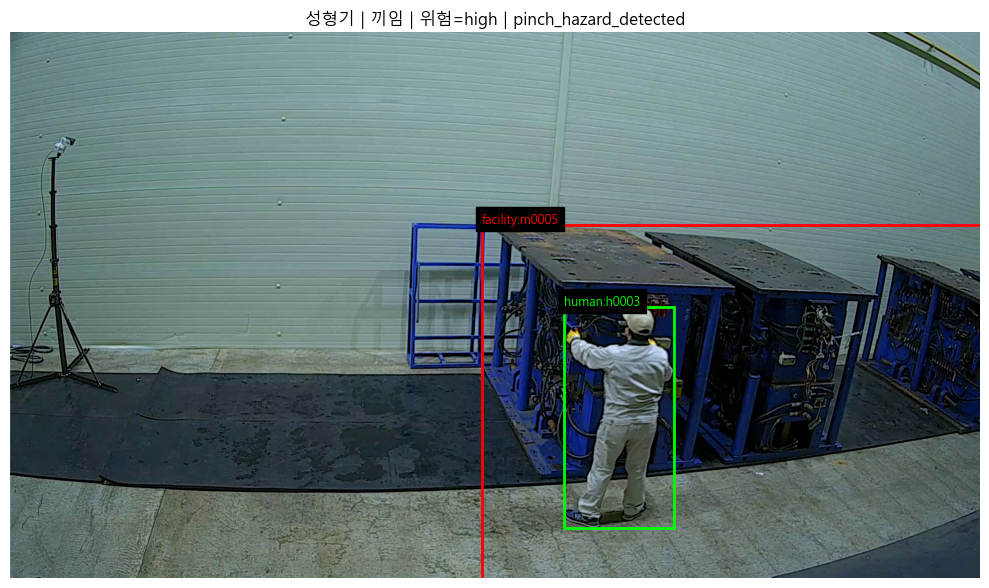

In [7]:
def visualize_hazard(case_id: str) -> None:
    """Vision AI 인식 결과 bbox 시각화."""
    case = CASE_BY_ID[case_id]
    _, objects = parse_label_objects(case["label_path"])
    img = Image.open(case["image_path"]).convert("RGB")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img)
    colors = {"human": "lime", "facility": "red"}
    for obj in objects:
        x1, y1, x2, y2 = obj["bbox_xyxy"]
        c = colors[obj["class"]]
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=c, linewidth=2))
        ax.text(x1, y1 - 5, f"{obj['class']}:{obj['id']}", color=c, fontsize=9, backgroundcolor="black")
    hazard = hazard_recognizer.recognize(case_id)
    ax.set_title(
        f"{case['facility_ko']} | {case['event_ko']} | 위험={hazard['overall_risk']} | {hazard['risk_summary']['alert']}"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()


visualize_hazard(demo_case["id"])

## 5. Agent Tool Schema & ToolBox

LLM Agent가 호출할 Tool을 OpenAI function calling 형식으로 정의하고 실행합니다.

In [8]:
TOOL_SCHEMAS: list[dict] = [
    {
        "type": "function",
        "function": {
            "name": "recognize_hazard",
            "description": "설비 CCTV 이미지에서 Vision AI로 설비·위험상황(끼임/근접)을 인식합니다.",
            "parameters": {
                "type": "object",
                "properties": {"case_id": {"type": "string", "description": "사례 ID (이미지 stem)"}},
                "required": ["case_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "search_similar_cases",
            "description": "ChromaDB Vector DB에서 유사 사고 사례를 검색합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    "case_id": {"type": "string", "description": "기준 이미지 ID (이미지 유사도 검색)"},
                    "query": {"type": "string", "description": "텍스트 질의 (텍스트 검색)"},
                    "top_k": {"type": "integer", "default": 3},
                },
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "search_safety_manual",
            "description": "산업 안전 매뉴얼(PDF→JSON)에서 점검·조치 절차를 검색합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string"},
                    "category": {"type": "string", "description": "jam, fall-down, hit 등 (선택)"},
                    "top_k": {"type": "integer", "default": 3},
                },
                "required": ["query"],
            },
        },
    },
]

tool_names = [t["function"]["name"] for t in TOOL_SCHEMAS]
print("등록 Tool:", ", ".join(tool_names))

등록 Tool: recognize_hazard, search_similar_cases, search_safety_manual


In [9]:
class SafetyToolBox:
    """Smart Factory Safety Agent Tool 실행기."""

    def __init__(self, encoder: SigLIP2Encoder, case_store: AccidentCaseStore,
                 manual_store: SafetyManualStore, hazard_recognizer: HazardRecognizer):
        self.encoder = encoder
        self.case_store = case_store
        self.manual = manual_store
        self.hazard = hazard_recognizer

    def recognize_hazard(self, case_id: str) -> dict:
        return self.hazard.recognize(case_id)

    def search_similar_cases(self, case_id: str | None = None, query: str | None = None, top_k: int = 3) -> dict:
        if case_id and case_id in CASE_BY_ID:
            hits = self.case_store.search_by_image(self.encoder, CASE_BY_ID[case_id]["image_path"], top_k=top_k)
        elif query:
            hits = self.case_store.search_by_text(self.encoder, query, top_k=top_k)
        else:
            return {"tool": "search_similar_cases", "error": "case_id 또는 query 필요"}
        compact = []
        for h in hits:
            m = h["metadata"]
            compact.append({
                "case_id": h["case_id"],
                "similarity": h["similarity"],
                "event": m.get("event"),
                "event_ko": m.get("event_ko"),
                "facility": m.get("facility"),
                "facility_ko": m.get("facility_ko"),
                "camera_id": m.get("camera_id"),
            })
        return {"tool": "search_similar_cases", "results": compact}

    def search_safety_manual(self, query: str, top_k: int = 3, category: str | None = None) -> dict:
        hits = self.manual.search(query, top_k=top_k, category=category)
        return {"tool": "search_safety_manual", "query": query, "results": hits}

    def dispatch(self, name: str, arguments: dict) -> dict:
        fn = getattr(self, name, None)
        if fn is None:
            return {"error": f"Unknown tool: {name}"}
        return fn(**arguments)


toolbox = SafetyToolBox(encoder, case_store, manual_store, hazard_recognizer)
print("SafetyToolBox 준비 완료")

SafetyToolBox 준비 완료


## 6. Agent Orchestrator — Plan → Act → Report

1. **Plan**: Vision AI 결과·질의 → Tool 목록 결정
2. **Act**: 유사 사례 검색 + 안전 매뉴얼 검색
3. **Report**: LLM 종합 판단 → 점검·조치 Markdown 보고서

In [10]:
def plan_tools(case_id: str, hazard_result: dict) -> list[dict]:
    """Vision AI 인식 결과 기반 Tool call 계획."""
    event = hazard_result.get("event", "jam")
    facility = hazard_result.get("facility", "")
    risk = hazard_result.get("overall_risk", "low")
    query = f"{event} {facility} {risk} 위험 조치 절차"
    return [
        {"name": "recognize_hazard", "arguments": {"case_id": case_id}},
        {"name": "search_similar_cases", "arguments": {"case_id": case_id, "top_k": TOP_K}},
        {"name": "search_safety_manual", "arguments": {"query": query, "category": event, "top_k": TOP_K}},
    ]


def llm_synthesize(hazard: dict, similar: list[dict], manual: list[dict]) -> str:
    """규칙 기반 LLM 종합 판단 (실무: GPT/Qwen API 호출)."""
    risk = hazard.get("overall_risk", "low")
    alert = hazard.get("risk_summary", {}).get("alert", "normal")
    facility_ko = hazard.get("facility_ko", "설비")
    event_ko = hazard.get("event_ko", "위험")

    if risk == "high":
        judgment = f"{facility_ko}에서 {event_ko} 위험이 **높음**. 작업자-설비 bbox 겹침({alert}) 확인. 즉시 LO/TO 후 현장 통제 필요."
        priority = "P1 — 긴급"
    elif risk == "medium":
        judgment = f"{facility_ko} 인근 작업자 근접({alert}). 설비 속도 감속·감시자 배치 권장."
        priority = "P2 — 주의"
    else:
        judgment = f"{facility_ko} 현재 안전 거리 유지. 정기 점검 스케줄 준수."
        priority = "P3 — 정상"

    if similar:
        top = similar[0]
        judgment += f" 유사 사례 `{top.get('case_id')}` (sim={top.get('similarity')})와 동일 {top.get('event_ko')} 패턴."
    if manual:
        judgment += f" 매뉴얼 [{manual[0].get('id')}] {manual[0].get('title')} 기준 조치."

    return f"**종합 판단** ({priority}): {judgment}"


def generate_safety_report(case_id: str, observations: list[dict]) -> str:
    ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
    hazard = next((o for o in observations if o.get("tool") == "recognize_hazard"), {})
    similar_obs = next((o for o in observations if o.get("tool") == "search_similar_cases"), {})
    manual_obs = next((o for o in observations if o.get("tool") == "search_safety_manual"), {})
    similar = similar_obs.get("results", [])
    manual = manual_obs.get("results", [])

    lines = [
        "# Smart Factory Safety Agent — 점검·조치 보고서",
        "",
        f"- **생성 시각**: {ts}",
        f"- **대상 사례**: `{case_id}`",
        f"- **설비**: {hazard.get('facility_ko', '?')} ({hazard.get('facility', '')})",
        f"- **위험 유형**: {hazard.get('event_ko', '?')} ({hazard.get('event', '')})",
        f"- **Vision AI 위험도**: {hazard.get('overall_risk', '?')} | alert={hazard.get('risk_summary', {}).get('alert', '?')}",
        "",
        "## 1. Vision AI 인식 결과",
    ]
    for rel in hazard.get("spatial_relations", []):
        lines.append(
            f"- `{rel['subject']}` {rel['predicate']} `{rel['object']}` "
            f"| {rel['semantic']} (risk={rel['risk_level']}, IoU={rel['metrics']['iou']})"
        )
    if hazard.get("vlm_analysis"):
        lines.append(f"- **Qwen3-VL**: {hazard['vlm_analysis']}")

    lines += ["", "## 2. 유사 사고 사례 (Vector DB)"]
    for r in similar:
        lines.append(
            f"- `{r['case_id']}` sim={r['similarity']} | {r['facility_ko']} / {r['event_ko']} / {r['camera_id']}"
        )

    lines += ["", "## 3. 안전 매뉴얼 근거"]
    for m in manual:
        lines.append(f"- **[{m['id']}] {m['title']}** (score={m['score']:.2f}): {m['content']}")

    lines += ["", "## 4. LLM 종합 판단", llm_synthesize(hazard, similar, manual), "", "## 5. 권장 조치"]
    actions = []
    if hazard.get("overall_risk") == "high":
        actions.append("즉시 설비 비상정지 및 LO/TO 수행")
        actions.append("끼임 원인 제거 후 2인 확인 재가동")
    elif hazard.get("overall_risk") == "medium":
        actions.append("작업자-설비 거리 확보·속도 20% 감속")
        actions.append("30분 내 재점검·CCTV 모니터링 강화")
    else:
        actions.append("정상 가동 유지·일상 점검 스케줄 준수")
    for m in manual[:1]:
        if "LO/TO" in m.get("content", ""):
            actions.append(f"매뉴얼 {m['id']} 절차 준수")
    lines.extend(f"- {a}" for a in dict.fromkeys(actions))
    lines += ["", "---", "*Smart Factory Safety Agent — Tool Calling 자동 생성*"]
    return "\n".join(lines)


class SafetyAgent:
    """설비 이미지 → Vision AI → Agent → Vector DB + 매뉴얼 → 보고서."""

    def __init__(self, toolbox: SafetyToolBox):
        self.toolbox = toolbox

    def run(self, case_id: str, verbose: bool = True) -> dict:
        self.toolbox.encoder._ensure_loaded()
        pre_hazard = self.toolbox.recognize_hazard(case_id)
        plan = plan_tools(case_id, pre_hazard)
        if verbose:
            print(f"[Plan] {len(plan)}개 Tool:")
            for step in plan:
                print(f"  → {step['name']}({json.dumps(step['arguments'], ensure_ascii=False)})")

        observations = []
        for step in plan:
            result = self.toolbox.dispatch(step["name"], step["arguments"])
            observations.append(result)
            if verbose:
                print(f"[Done] {step['name']}")

        report = generate_safety_report(case_id, observations)
        return {"case_id": case_id, "plan": plan, "observations": observations, "report": report}

    def save_report(self, result: dict) -> Path:
        ts = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
        path = REPORT_DIR / f"safety_{result['case_id']}_{ts}.md"
        path.write_text(result["report"], encoding="utf-8")
        return path


agent = SafetyAgent(toolbox)
print("SafetyAgent 준비 완료")

SafetyAgent 준비 완료


## 7. 시나리오 — 3종 설비 위험 점검

성형기·밀링기·사출기 샘플 각 1장에 대해 Agent 파이프라인을 실행합니다.

In [11]:
def pick_sample(facility: str) -> str:
    for c in CASE_INDEX:
        if c["facility"] == facility:
            return c["id"]
    raise ValueError(f"{facility} 샘플 없음")


SAMPLE_CASES = {
    "성형기": pick_sample("molding-machine"),
    "밀링기": pick_sample("milling-machine"),
    "사출기": pick_sample("injection-machine"),
}
print("샘플 사례:", SAMPLE_CASES)

샘플 사례: {'성형기': 'human-accident_jam_rgb_0957_cctv1_01', '밀링기': 'human-accident_jam_rgb_1048_cctv3_01', '사출기': 'human-accident_jam_rgb_1892_cctv3_01'}


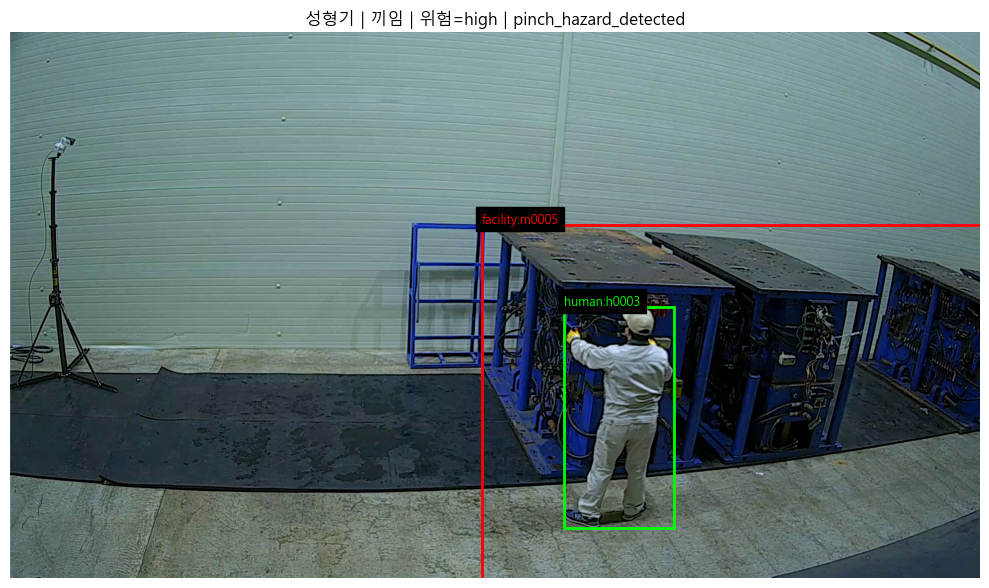

[Plan] 3개 Tool:
  → recognize_hazard({"case_id": "human-accident_jam_rgb_0957_cctv1_01"})
  → search_similar_cases({"case_id": "human-accident_jam_rgb_0957_cctv1_01", "top_k": 3})
  → search_safety_manual({"query": "jam molding-machine high 위험 조치 절차", "category": "jam", "top_k": 3})
[Done] recognize_hazard
[Done] search_similar_cases
[Done] search_safety_manual


# Smart Factory Safety Agent — 점검·조치 보고서

- **생성 시각**: 2026-07-09 13:46 UTC
- **대상 사례**: `human-accident_jam_rgb_0957_cctv1_01`
- **설비**: 성형기 (molding-machine)
- **위험 유형**: 끼임 (jam)
- **Vision AI 위험도**: high | alert=pinch_hazard_detected

## 1. Vision AI 인식 결과
- `h0003` overlaps_with `m0005` | pinch_hazard_overlap (risk=high, IoU=0.074)
- **Qwen3-VL**: 이 이미지의 CCTV 장면에서는 성형기(molding-machine) 주변에 작업자가 있는 상황을 보여주고 있습니다. 이는 작업자와 기계 사이에 발생할 수 있는 **압박 위험**(pinch hazard)을 포함하는 중요한 안전 문제를 나타냅니다.

### 1. **위험 요소 분석**

- **작업자 위치**: 작업자는 성형기(Blue Machine)의 왼쪽 부분에 서 있으며, 손과 팔로 기계 내부의 연결된 코어 및 전선들을 조작하고 있음.
- **기계 구조**: 성형기는 여러 개의 파란색 프레임으로 구성되어 있고, 그 중 일부는 뚜껑 없이 열려 있어 내부 부품들이 노출됨.
- **작업 환경**: 작업자는 기계 앞에 서서 작동하며, 기계가 움직

## 2. 유사 사고 사례 (Vector DB)
- `human-accident_jam_rgb_0957_cctv1_01` sim=1.0 | 성형기 / 끼임 / cctv1
- `human-accident_jam_rgb_0957_cctv1_03` sim=0.995 | 성형기 / 끼임 / cctv1
- `human-accident_jam_rgb_0957_cctv1_04` sim=0.995 | 성형기 / 끼임 / cctv1

## 3. 안전 매뉴얼 근거

## 4. LLM 종합 판단
**종합 판단** (P1 — 긴급): 성형기에서 끼임 위험이 **높음**. 작업자-설비 bbox 겹침(pinch_hazard_detected) 확인. 즉시 LO/TO 후 현장 통제 필요. 유사 사례 `human-accident_jam_rgb_0957_cctv1_01` (sim=1.0)와 동일 끼임 패턴.

## 5. 권장 조치
- 즉시 설비 비상정지 및 LO/TO 수행
- 끼임 원인 제거 후 2인 확인 재가동

---
*Smart Factory Safety Agent — Tool Calling 자동 생성*

보고서 저장: C:\MyCursorLab\09_Visual_RAG\data\agent\reports\safety_human-accident_jam_rgb_0957_cctv1_01_20260709_134644.md


In [12]:
facility_name = "성형기"
case_id = SAMPLE_CASES[facility_name]

visualize_hazard(case_id)
result = agent.run(case_id)
display(Markdown(result["report"]))
saved = agent.save_report(result)
print(f"보고서 저장: {saved}")

In [13]:
summary_rows = []
for label, case_id in SAMPLE_CASES.items():
    r = agent.run(case_id, verbose=False)
    hazard = next(o for o in r["observations"] if o["tool"] == "recognize_hazard")
    agent.save_report(r)
    summary_rows.append({
        "설비": label,
        "case_id": case_id,
        "위험유형": hazard["event_ko"],
        "위험도": hazard["overall_risk"],
        "alert": hazard["risk_summary"]["alert"],
    })

pd.DataFrame(summary_rows)

,설비,case_id,위험유형,위험도,alert
0,성형기,human-accident_jam_rgb_0957_cctv1_01,끼임,high,pinch_hazard_detected
1,밀링기,human-accident_jam_rgb_1048_cctv3_01,끼임,high,pinch_hazard_detected
2,사출기,human-accident_jam_rgb_1892_cctv3_01,끼임,high,pinch_hazard_detected


## 8. (선택) Qwen3-VL Vision AI 강화

`USE_QWEN = True`로 설정하고 커널 재시작 후 §4~§7을 다시 실행하면
Qwen3-VL이 CCTV 장면 설명을 보고서에 추가합니다.

> GPU 12GB 이상 권장. YOLO 탐지와 결합하려면 `07_Vision_Language_Model/11_yolo_qwen3_smart_factory_accident_analysis.ipynb`를 참고하세요.